Pente finale w = 0.7764
Ordonnée à l'origine b = 1.9867


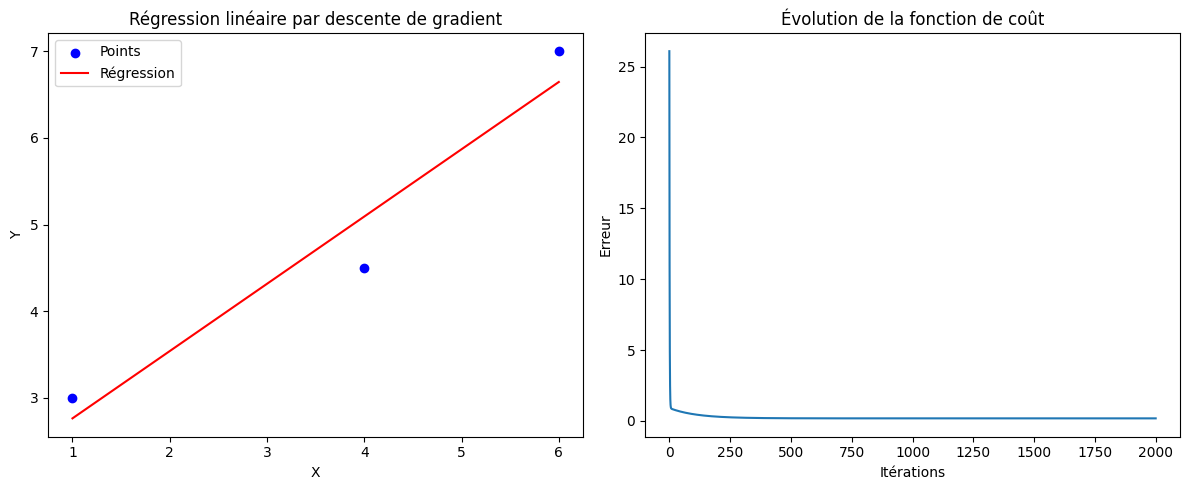

Prédictions
-----------
y_septembre (x=7) = 7.4
y_novembre (x=5) = 5.9


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Données : 3 points non alignés
# -----------------------------
X = np.array([1,4,6], dtype=float)
Y = np.array([3,4.5,7], dtype=float)

# Normalisation optionnelle (ici pas nécessaire)
n = len(X)

# -----------------------------
# 2. Paramètres du modèle
# -----------------------------
w = 0.0   # pente
b = 0.0   # intercept
lr = 0.01 # learning rate
epochs = 2000

loss_history = []

# -----------------------------
# 3. Descente de gradient
# -----------------------------
for _ in range(epochs):
    Y_pred = w * X + b

    # Erreur quadratique moyenne
    loss = (1/n) * np.sum((Y_pred - Y)**2)
    loss_history.append(loss)

    # Gradients
    dw = (2/n) * np.sum((Y_pred - Y) * X)
    db = (2/n) * np.sum(Y_pred - Y)

    # Mise à jour
    w -= lr * dw
    b -= lr * db

print(f"Pente finale w = {w:.4f}")
print(f"Ordonnée à l'origine b = {b:.4f}")

# -----------------------------
# 4. Affichage
# -----------------------------
plt.figure(figsize=(12,5))

# Graphique 1 : points + droite
plt.subplot(1,2,1)
plt.scatter(X, Y, color='blue', label='Points')
plt.plot(X, w*X + b, color='red', label='Régression')
plt.title("Régression linéaire par descente de gradient")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()

# Graphique 2 : évolution de l'erreur
plt.subplot(1,2,2)
plt.plot(loss_history)
plt.title("Évolution de la fonction de coût")
plt.xlabel("Itérations")
plt.ylabel("Erreur")

plt.tight_layout()
plt.show()

# -----------------------------
# 5. Prédictions
# -----------------------------
print("Prédictions")
print("-----------")
print(f"y_septembre (x=7) = {b+w*7:.1f}")
print(f"y_novembre (x=5) = {b+w*5:.1f}")

w final = 8.8933
b final = -16.7247


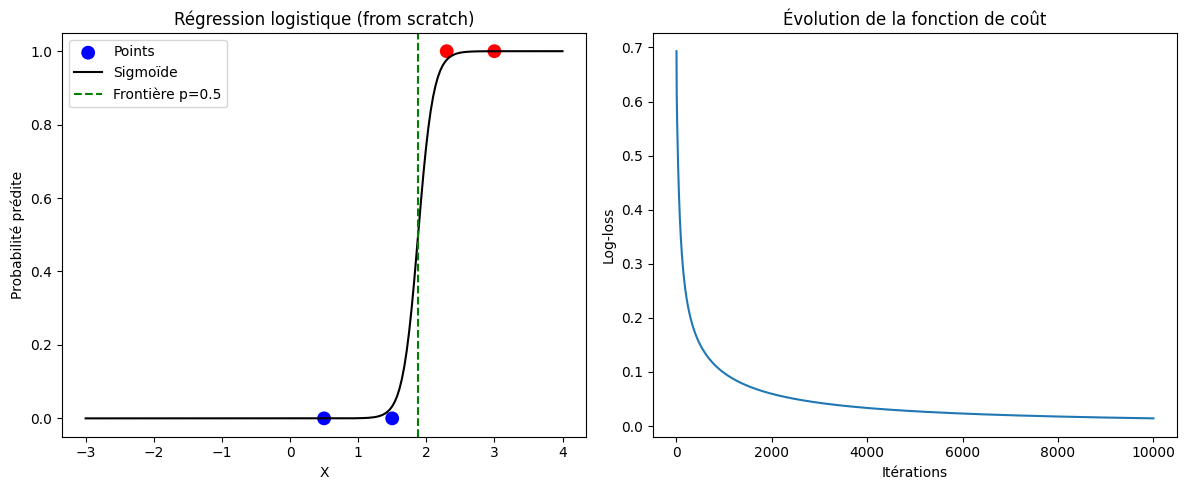

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Données
# -----------------------------
X = np.array([0.5,1.5,2.3,3], dtype=float)
Y = np.array([0,0,1,1], dtype=float)

n = len(X)

# -----------------------------
# 2. Paramètres du modèle
# -----------------------------
w = 0.0
b = 0.0
lr = 0.2
epochs = 10000

loss_history = []

# Fonction sigmoïde
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# -----------------------------
# 3. Descente de gradient
# -----------------------------
for _ in range(epochs):
    z = w * X + b
    y_pred = sigmoid(z)

    # Fonction de coût log-loss
    loss = -(1/n) * np.sum(Y * np.log(y_pred + 1e-9) + (1 - Y) * np.log(1 - y_pred + 1e-9))
    loss_history.append(loss)

    # Gradients
    dw = (1/n) * np.sum((y_pred - Y) * X)
    db = (1/n) * np.sum(y_pred - Y)

    # Mise à jour
    w -= lr * dw
    b -= lr * db

print(f"w final = {w:.4f}")
print(f"b final = {b:.4f}")

# -----------------------------
# 4. Affichage
# -----------------------------
plt.figure(figsize=(12,5))

# Graphique 1 : points + frontière de décision
plt.subplot(1,2,1)
plt.scatter(X, Y, c=Y, cmap='bwr', s=80, label="Points")

# Courbe logistique
x_line = np.linspace(-3, 4, 200)
y_line = sigmoid(w * x_line + b)
plt.plot(x_line, y_line, 'k-', label="Sigmoïde")

# Ligne de décision (p=0.5)
decision_x = -b / w
plt.axvline(decision_x, color='green', linestyle='--', label="Frontière p=0.5")

plt.title("Régression logistique (from scratch)")
plt.xlabel("X")
plt.ylabel("Probabilité prédite")
plt.legend()

# Graphique 2 : évolution du coût
plt.subplot(1,2,2)
plt.plot(loss_history)
plt.title("Évolution de la fonction de coût")
plt.xlabel("Itérations")
plt.ylabel("Log-loss")

plt.tight_layout()
plt.show()


w = [0.96815842 0.96815842]
b = -2.909999999999982


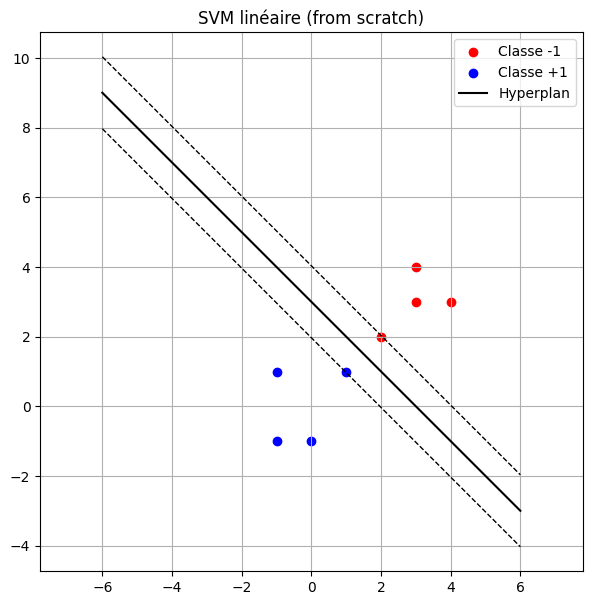

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Création de deux nuages de points
# -----------------------------
# Points de la classe +1
X_pos = np.array([
    [2, 2],
    [3, 3],
    [3, 4],
    [4, 3]
])

# Points de la classe -1
X_neg = np.array([
    [1, 1],
    [0, -1],
    [-1, 1],
    [-1, -1]
])

# Concaténation des données
X = np.vstack((X_pos, X_neg))

# Labels correspondants
Y = np.hstack((
    np.ones(len(X_pos)),      # +1
    -np.ones(len(X_neg))      # -1
))
n = len(Y)

# -----------------------------
# 2. Paramètres du modèle
# -----------------------------
w = np.zeros(2)
b = 0.0
lr = 0.01
epochs = 20000
C = 1.0   # coefficient de régularisation

# -----------------------------
# 3. Descente de gradient SVM
# -----------------------------
for _ in range(epochs):
    # Calcul des marges : y_i (w·x_i + b)
    margins = Y * (X.dot(w) + b)

    # Hinge loss : max(0, 1 - margin)
    # Gradient de w
    dw = w.copy()  # dérivée de ||w||² / 2
    for i in range(n):
        if margins[i] < 1:
            dw -= C * Y[i] * X[i]

    # Gradient de b
    db = 0
    for i in range(n):
        if margins[i] < 1:
            db -= C * Y[i]

    # Mise à jour
    w -= lr * dw
    b -= lr * db

print("w =", w)
print("b =", b)

# -----------------------------
# 4. Affichage
# -----------------------------
plt.figure(figsize=(7,7))

# Points
plt.scatter(X_pos[:,0], X_pos[:,1], color='red', label='Classe -1')
plt.scatter(X_neg[:,0], X_neg[:,1], color='blue', label='Classe +1')

# Ligne de séparation
x_line = np.linspace(-6, 6, 200)
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, 'k-', label='Hyperplan')

# Marges : w·x + b = ±1
y_margin1 = -(w[0] * x_line + b - 1) / w[1]
y_margin2 = -(w[0] * x_line + b + 1) / w[1]
plt.plot(x_line, y_margin1, 'k--', linewidth=1)
plt.plot(x_line, y_margin2, 'k--', linewidth=1)

plt.title("SVM linéaire (from scratch)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()
